# Week 1 Notebook: Build a Shallow Neural Network for Regression using PyTorch

**Goal:** understand model definition, initialization control, and fair training comparisons across gradient methods.

## Architecture
We want:
- input dimension: 6
- hidden dimension: 16
- output dimension: 1
- activation: `Tanh` (Hyperbolic Tangent)

Mathematically:

- `X` has shape `(n, 6)`
- hidden layer computes `h = Tanh(X W1^T + b1)`
- output computes `y_hat = h W2^T + b2`


## Part 0: Predict Shapes (before coding)
Write  predictions for:
1. `W1` shape for `Linear(6, 16)` A: W1.shape = (16, 6)
2. `b1` shape A: b1.shape = (16,)
3. hidden activation `h` shape A: h.shape = (n, 16)
4. `W2` shape for `Linear(16, 1)` A: W2.shape = (1, 16)
5. `b2` shape A: b2.shape = (1,)
6. output `y_hat` shape A: y_hat.shape = (n, 1)



In [101]:
import copy
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
print("pytorch version:",  torch.__version__)


pytorch version: 2.2.2


## Part 1: First operations and examples that call `torch` and `torch.nn`

Understand:
- How to create a tensor and check its shape and data type
- How to create a linear layer and check its parameters and shapes
- How to manipulate tensors with operations like addition, multiplication, and activation functions
- How to use the `torch.manual_seed()` function to set the random seed for reproducibility

In [44]:
# Tensor basics
x = torch.tensor([1.0, 2.0, 3.0])
print(x)
print("shape:", x.shape)
print("dtype:", x.dtype)

# one sample with 6 features (vector form)
x_vec = torch.tensor([1., 2., 3., 4., 5., 6.], dtype=torch.float32)
print("x_vec shape:", x_vec.shape)   # (6,)

# same sample, but batch form (preferred for model input)
x_batch_0 = x_vec.unsqueeze(0)
print("x_batch shape:", x_batch_0.shape)  # (1, 6)

# same sample, but batch form with unsqueeze(1) 
x_batch_1 = x_vec.unsqueeze(1)
print("x_batch_1 shape:", x_batch_1.shape)  # (6, 1)

# Define a linear layer with 6 input features and 16 output features
linear_layer = nn.Linear(6, 16)
print("W1 shape:", linear_layer.weight.shape)  # (16, 6)
print("b1 shape:", linear_layer.bias.shape)    # (16,)
print("W1: ", linear_layer.weight)
print("b1: ", linear_layer.bias)
print("Remark: the weights and biases are initialized randomly.")

# Reproducibility: set the random seed for torch
torch.manual_seed(42)
linear_layer = nn.Linear(6, 16)
print("W1 shape:", linear_layer.weight.shape)  # (16, 6)
print("b1 shape:", linear_layer.bias.shape)    # (16,)
print("W1: ", linear_layer.weight)
print("b1: ", linear_layer.bias)

# With another seed, the weights and biases will be different
torch.manual_seed(123)
linear_layer = nn.Linear(6, 16)
print("W1 shape:", linear_layer.weight.shape)  # (16, 6)
print("b1 shape:", linear_layer.bias.shape)    # (16,)
print("W1: ", linear_layer.weight)
print("b1: ", linear_layer.bias)

# Apply the linear layer to the input tensor
output = linear_layer(x_batch_0)
print("Output shape:", output.shape)  # (1, 16)

# Simple arithmetic operations on tensors
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])
# Addition
c = a + b
print("Addition: ", c)
# Transpose
a_t = torch.reshape(a, (3, 1))
# Multiplication (element-wise)
d = a * b
print("Multiplication: ", d)
# Matrix multiplication
W = torch.tensor([[1.0, 2.0, -1.0], [3.0, 4.0, 5.0]]) # (2, 3)
X = torch.tensor([[1.0, 2.0], [4.0, 5.0], [7.0, 8.0]]) # (3, 2)

Y = W @ X  # Matrix multiplication
print("Matrix multiplication result: ", Y)




tensor([1., 2., 3.])
shape: torch.Size([3])
dtype: torch.float32
x_vec shape: torch.Size([6])
x_batch shape: torch.Size([1, 6])
x_batch_1 shape: torch.Size([6, 1])
W1 shape: torch.Size([16, 6])
b1 shape: torch.Size([16])
W1:  Parameter containing:
tensor([[ 0.2104, -0.0379, -0.0710,  0.0478, -0.3128,  0.0472],
        [ 0.1373,  0.3490, -0.1271,  0.1470,  0.4080, -0.1751],
        [ 0.3881, -0.2027,  0.1800,  0.1599,  0.1140,  0.3228],
        [-0.1650,  0.1073,  0.0023, -0.3071, -0.0991, -0.2726],
        [ 0.1805,  0.0367,  0.0400, -0.1239,  0.0020, -0.1270],
        [ 0.1173,  0.3965,  0.0618, -0.1808, -0.2494,  0.0312],
        [-0.3029, -0.3069, -0.2657, -0.1387,  0.0302,  0.2811],
        [ 0.1581,  0.3128, -0.2563,  0.0345, -0.3629,  0.2342],
        [ 0.0851,  0.3949, -0.2904,  0.3274,  0.3447,  0.3301],
        [ 0.0583,  0.3712,  0.2726,  0.3046, -0.0265, -0.3133],
        [-0.0051,  0.0766, -0.2781, -0.2342, -0.3914, -0.1431],
        [ 0.3556,  0.0698, -0.0249,  0.0164,  0.

## Part 2: Toy Data Generation using `torch.randn` and `torch.rand`

Understand:
- How to generate random data using `torch.randn` and `torch.rand`
- How to set the random seed for reproducibility
- How to create toy datasets for regression experiments through adding noise to a linear function of the input features


In [45]:
torch.manual_seed(0) # Reproducibility: set the random seed for torch
N = 1000
d = 6
X = torch.randn(N, d)  # Random input features of shape (N, d)
W_true =  torch.linspace(1, 10, d).reshape(d, 1)  # True weights of shape (d, 1)
b_true = torch.tensor([5.0])  # True bias of shape (1,)
# Generate target values with some noise
noise = torch.randn(N, 1) * 0.5  # Noise with standard deviation of 0.5
y = X @ W_true + b_true + noise  #

## Part 3: Shallow Neural Network Model Definition using `torch.nn.Module`

Understand:
- why we subclass `torch.nn.Module`
- how parameters are registered by layers
- how to define the forward pass of the model
- how instantiate the model 
- how to access the model parameters and their shapes
- how to call a loss function and compute the loss using `torch.nn.MSELoss`
- how save the model initialized weights and biases to restore them later for comparison with the trained model weights and biases using `copy.deepcopy(model.state_dict())`
- how to use `backward()` to compute gradients
- how to use `torch.no_grad()` to update the model parameters manually

In [46]:
class ShallowNN(nn.Module):
    def __init__(
            self, 
            input_dim: int =6,
            hidden_dim: int =16,
            output_dim: int =1,
            ):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.Tanh()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        hidden = self.fc1(x)
        z = self.activation(hidden)
        output = self.fc2(z)
        return output


In [87]:
torch.manual_seed(0) # Reproducibility: set the random seed for torch
# Instantiate the model
model = ShallowNN(input_dim=6, hidden_dim=16, output_dim=1)
print(model)

# access to model parameters and their shapes
for name, param in model.named_parameters():
    print(f"Parameter name: {name}, shape: {param.shape}")

# Calculate the output of the model for a batch of input data
output = model(X)
print("Output shape:", output.shape)  # (N, 1)

# Use state_dict to access model parameters
state_dict = model.state_dict()
for name, param in state_dict.items():
    print(f"Parameter name: {name}, shape: {param.shape}")

# Access to a specific parameter (e.g., first weight of the first layer)
first_weight = state_dict['fc1.weight'][0, 0]
print("First weight of the first layer:", first_weight)



ShallowNN(
  (fc1): Linear(in_features=6, out_features=16, bias=True)
  (activation): Tanh()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)
Parameter name: fc1.weight, shape: torch.Size([16, 6])
Parameter name: fc1.bias, shape: torch.Size([16])
Parameter name: fc2.weight, shape: torch.Size([1, 16])
Parameter name: fc2.bias, shape: torch.Size([1])
Output shape: torch.Size([1000, 1])
Parameter name: fc1.weight, shape: torch.Size([16, 6])
Parameter name: fc1.bias, shape: torch.Size([16])
Parameter name: fc2.weight, shape: torch.Size([1, 16])
Parameter name: fc2.bias, shape: torch.Size([1])
First weight of the first layer: tensor(-0.0031)


In [94]:
# Initialisation cell


# 1) Fix the random seed once
torch.manual_seed(0)

# 2) Build a reference model once
reference_model = ShallowNN(input_dim=6, hidden_dim=16, output_dim=1)

# 3) Save its initial parameters
initial_state = copy.deepcopy(reference_model.state_dict())

# Optional: check the starting loss for the reference initialization
loss_fn = nn.MSELoss()
with torch.no_grad(): # it tells PyTorch not to compute gradients for this operation
    initial_loss = loss_fn(reference_model(X), y) 
print("Initial loss:", initial_loss.item())


# Calculate the gradients of the loss with respect to the model parameters.
# We need to track the gradient. 
initial_loss_with_grad = loss_fn(reference_model(X), y)
initial_loss_with_grad.backward()  # This will compute the gradients and store them in the .grad attribute of each parameter

# print the gradient with respect to W1 the weight of the first layer
print("Gradient with respect to W1:", reference_model.fc1.weight.grad.shape)



Initial loss: 262.01727294921875
Gradient with respect to W1: torch.Size([16, 6])


## Part 4: Model Training and Evaluation

Understand:
- how to define a loss function using the `torch.nn` module
- how to set up an optimizer from `torch.optim` and call `optimizer.step()` to update the model parameters
- how to implement two variants of the gradient descent: mini batch gradient with uniform draw with replacement and mini batch gradient with permutation draw without replacement. The first is based in the number of iterations and the second is based on the number of epochs.


In [95]:
# Variant 1: Mini batch gradient descent with uniform draw with replacement
# 
# Parameters:
# - max_iterations: The maximum number of iterations for training.
# - lr: The learning rate for the optimizer.
# - b: The batch size for mini-batch gradient descent.

max_iterations = 1000 # for the mini batch gradient descent with uniform draw with replacement
lr = 0.01 # learning rate
b = 32 # batch size


# Create a fresh model for variant 1 with the same initial parameters as the reference model (see Cell above for initial_state)
model_variant1 = ShallowNN(input_dim=6, hidden_dim=16, output_dim=1)
model_variant1.load_state_dict(initial_state)  # Load the initial parameters into the new model

# Set up an optimizer (e.g., SGD) for the model parameters
optimizer = torch.optim.SGD(model_variant1.parameters(), lr=lr)

loss_history_1 = []  # To store the loss values for each iteration
start_time = time.time()
for t in range(max_iterations):
    # Randomly sample a mini-batch of data with replacement
    indices = torch.randint(0, N, (b,))
    X_batch = X[indices]
    y_batch = y[indices]

    # Zero the gradients before the backward pass because PyTorch accumulates gradients by default
    optimizer.zero_grad()

    # Forward pass: compute the model output for the mini-batch
    output = model_variant1(X_batch)

    # Compute the loss for the mini-batch
    loss = loss_fn(output, y_batch)

    # Store the loss value for this iteration
    if t % 10 == 0:  # Store loss every 10 iterations to reduce memory usage
        loss_history_1.append(loss.item())

    # Backward pass: compute gradients of the loss with respect to model parameters
    loss.backward()

    # Update model parameters using the optimizer. The optimizer.step() method updates the parameters based on the computed gradients and the learning rate.
    optimizer.step()
    

variant1_time = time.time() - start_time
print(f"Training time for variant 1 (mini batch gradient descent with uniform draw with replacement): {variant1_time:.4f} seconds")

# Print the final loss after training for variant 1
final_output = model_variant1(X)
final_loss = loss_fn(final_output, y)
print("Final loss after training for variant 1:", final_loss.item())

Training time for variant 1 (mini batch gradient descent with uniform draw with replacement): 2.2222 seconds
Final loss after training for variant 1: 0.572301983833313


In [96]:
# Variant 2: Mini batch gradient descent with permutation draw without replacement
# 
# Parameters:
# - max_iterations: The maximum number of iterations for training.
# - lr: The learning rate for the optimizer.
# - b: The batch size for mini-batch gradient descent.

max_epochs = 1000 # for the mini batch gradient descent with permutation draw without replacement

lr = 0.01 # learning rate
b = 32 # batch size
k = N // b # number of batches per epoch


# Create a fresh model for variant 1 with the same initial parameters as the reference model (see Cell above for initial_state)
model_variant2 = ShallowNN(input_dim=6, hidden_dim=16, output_dim=1)
model_variant2.load_state_dict(initial_state)  # Load the initial parameters into the new model

# Set up an optimizer (e.g., SGD) for the model parameters
optimizer = torch.optim.SGD(model_variant2.parameters(), lr=lr)




t = 0  # Initialize the iteration counter for loss storage
start_time = time.time()
loss_history_2 = []  # To store the loss values for each iteration
for epoch in range(max_epochs):
    # Shuffle the dataset indices for each epoch
    indices = torch.randperm(N)
    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for batch_idx in range(k):
        t += 1  # Increment the iteration counter
        start_idx = batch_idx * b
        end_idx = start_idx + b
        X_batch = X_shuffled[start_idx:end_idx]
        y_batch = y_shuffled[start_idx:end_idx]

        # Zero the gradients before the backward pass
        optimizer.zero_grad()

        # Forward pass: compute the model output for the mini-batch
        output = model_variant2(X_batch)

        # Compute the loss for the mini-batch
        loss = loss_fn(output, y_batch)

        # Store the loss value for this iteration
        if t % 50 == 0:  # Store loss every 50 iterations to reduce memory usage
            loss_history_2.append(loss.item())
            print(f"Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item()}")

        # Backward pass: compute gradients of the loss with respect to model parameters
        loss.backward()

        # Update model parameters using the optimizer
        optimizer.step()

variant2_time = time.time() - start_time
print(f"Training time for variant 2 (mini batch gradient descent with permutation draw without replacement): {variant2_time:.4f} seconds")

# Print the final loss after training for variant 2
final_output = model_variant2(X)
final_loss = loss_fn(final_output, y)
print("Final loss after training for variant 2:", final_loss.item())

Epoch 1, Batch 18, Loss: 14.556537628173828
Epoch 3, Batch 6, Loss: 8.593710899353027
Epoch 4, Batch 25, Loss: 1.6083381175994873
Epoch 6, Batch 13, Loss: 1.8127028942108154
Epoch 8, Batch 1, Loss: 4.358982086181641
Epoch 9, Batch 20, Loss: 0.8024426698684692
Epoch 11, Batch 8, Loss: 0.5823323130607605
Epoch 12, Batch 27, Loss: 0.29967832565307617
Epoch 14, Batch 15, Loss: 1.3946408033370972
Epoch 16, Batch 3, Loss: 0.5220280885696411
Epoch 17, Batch 22, Loss: 0.5027416348457336
Epoch 19, Batch 10, Loss: 0.4076206088066101
Epoch 20, Batch 29, Loss: 0.35815685987472534
Epoch 22, Batch 17, Loss: 0.6862683296203613
Epoch 24, Batch 5, Loss: 0.41295531392097473
Epoch 25, Batch 24, Loss: 2.2243266105651855
Epoch 27, Batch 12, Loss: 0.5216847658157349
Epoch 29, Batch 0, Loss: 2.4811389446258545
Epoch 30, Batch 19, Loss: 0.3172517716884613
Epoch 32, Batch 7, Loss: 0.3746027946472168
Epoch 33, Batch 26, Loss: 0.2895432114601135
Epoch 35, Batch 14, Loss: 0.5069818496704102
Epoch 37, Batch 2, Los

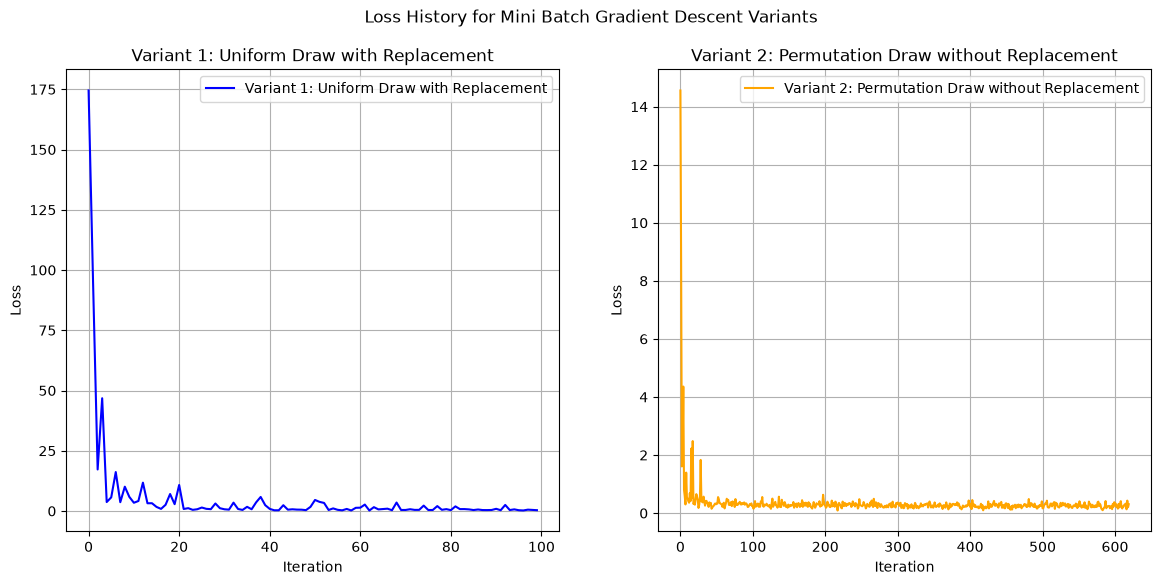

In [ ]:
# Plot the loss history for both variants in side to side subplots for comparison


plt.figure(figsize=(14, 6))
# Plot for variant 1
plt.subplot(1, 2, 1)
plt.plot(loss_history_1, label='Variant 1: Uniform Draw with Replacement', color='blue')
plt.title('Variant 1: Uniform Draw with Replacement')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Plot for variant 2
plt.subplot(1, 2, 2)
plt.plot(loss_history_2, label='Variant 2: Permutation Draw without Replacement', color='orange')
plt.title('Variant 2: Permutation Draw without Replacement')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.suptitle('Loss History for Mini Batch Gradient Descent Variants')
plt.show()

Epoch 0, Loss: 262.01727294921875


Epoch 50, Loss: 12.227823257446289
Epoch 100, Loss: 6.527782917022705
Epoch 150, Loss: 4.355091571807861
Epoch 200, Loss: 3.112567186355591
Epoch 250, Loss: 2.276540517807007
Epoch 300, Loss: 1.7037218809127808
Epoch 350, Loss: 1.3276855945587158
Epoch 400, Loss: 1.0884544849395752
Epoch 450, Loss: 0.9342988729476929
Epoch 500, Loss: 0.8297632932662964
Epoch 550, Loss: 0.7542654275894165
Epoch 600, Loss: 0.696662425994873
Epoch 650, Loss: 0.6508407592773438
Epoch 700, Loss: 0.6132461428642273
Epoch 750, Loss: 0.5816760063171387
Epoch 800, Loss: 0.5546849370002747
Epoch 850, Loss: 0.5312798619270325
Epoch 900, Loss: 0.5107500553131104
Epoch 950, Loss: 0.49257153272628784
Training time for full batch gradient descent: 10.8021 seconds


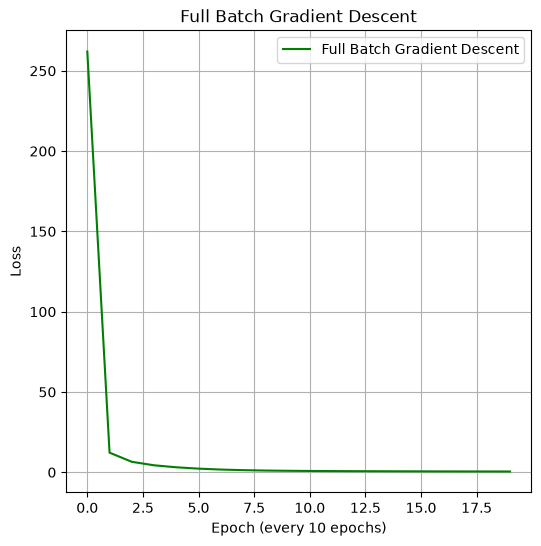

In [100]:
# Full batch gradient descent
# 
# Parameters:
# - max_epochs: The maximum number of epochs for training.
# - lr: The learning rate for the optimizer.
max_epochs = 1000 # for the full batch gradient descent
lr = 0.01 # learning rate
# 
# Create a fresh model for variant 1 with the same initial parameters as the reference model (see Cell above for initial_state)
model_full_batch = ShallowNN(input_dim=6, hidden_dim=16, output_dim=1)
model_full_batch.load_state_dict(initial_state)  # Load the initial parameters into the new model

# Set up an optimizer (e.g., SGD) for the model parameters
optimizer = torch.optim.SGD(model_full_batch.parameters(), lr=lr)


loss_history_full_batch = []  # To store the loss values for each epoch
start_time = time.time()
for epoch in range(max_epochs):
    # Zero the gradients before the backward pass
    optimizer.zero_grad()

    # Forward pass: compute the model output for the entire dataset
    output = model_full_batch(X)

    # Compute the loss for the entire dataset
    loss = loss_fn(output, y)

    # Store the loss value for this epoch
    if epoch % 50 == 0:  # Store loss every 50 epochs to reduce memory usage
        loss_history_full_batch.append(loss.item())
        print(f"Epoch {epoch}, Loss: {loss.item()}")

    # Backward pass: compute gradients of the loss with respect to model parameters
    loss.backward()

    # Update model parameters using the optimizer
    optimizer.step()

full_batch_end = time.time() - start_time
print(f"Training time for full batch gradient descent: {full_batch_end:.4f} seconds")


# Plot the loss history for full batch gradient descent
plt.figure(figsize=(6, 6))
plt.plot(loss_history_full_batch, label='Full Batch Gradient Descent', color='green')
plt.title('Full Batch Gradient Descent')
plt.xlabel('Epoch (every 50 epochs)')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()    

## Observations and fix

My first mistake was that the variants did not start from the same initial point. Because the model parameters were randomly initialized, each run could begin with different weights, which made the results hard to compare fairly.

I fixed that by building one reference model once, saving its initial weights in `initial_state`, and then restoring those exact weights before every variant. That gives every method the same starting point and a fresh optimizer state.

The workflow I will be using in future development is: 

- Build one reference initialization once.
- Save its weights.
- Before each variant:
    - Create a new model instance
    - Load the saved weights
    - Create a new optimizer
- Run that variant
- Record initial and final loss

How PyTorch updates weights:
- `loss.backward()` computes gradients for the current model parameters.
- `optimizer.step()` uses those gradients to update the weights in place.
- `optimizer.zero_grad()` clears old gradients before the next step.

That means if I reuse the same model object after training, I am no longer starting from the same weights. For later experiments, I should always create a fresh model, load `initial_state`, and create a fresh optimizer so I avoid the same fairness issue again.